In [ ]:
# Capstone -- function 2 (2D)

import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial import Delaunay  # convex-hull membership check for the proposal

from bayes_tools import (
    load_collected, save_proposal,
    fitting,
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ucb_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    compare_kappa_proposals, print_kappa_comparison,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_2d_bo, plot_bo_diagnostics, plot_loo_calibration, plot_kappa_sensitivity,
    plot_acquisition_backtest,
)


# Function 2

2D. We propose with `ucb`, `KAPPA = 1.0`, holding `x1` at the incumbent and scanning `x0` only.

Since round 2 I've been on UCB rather than EI. I briefly raised `kappa` to 3.0 and that was wrong — the write-up below records why, because the mistake is the useful part. No real evaluation was ever spent at 3.0.

The backtest keeps reordering its top few configs week to week, which is worth remembering before leaning on it.

In [ ]:
X_initial = np.load("initial_data/function_2/initial_inputs.npy")
y_initial = np.load("initial_data/function_2/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

# Loaded once and never modified.
new_X = np.empty((0, D))
new_y = np.empty((0,))

## Update this once per week

Nothing to edit here now — the collected observations come from `weekly_data/function_2/`. Run `record_results.py` first so last week's result is in place before this notebook proposes.

In [ ]:
# My collected observations, from weekly_data/function_2/. I run
# record_results.py before opening this notebook so the results are already
# there. pending_X holds a proposal with no result yet; it never reaches the
# model.
#
# Provenance of the collected points, oldest first:
#   - week 2

new_X, new_y, pending_X = load_collected(2, D)

print("observations collected so far:", len(new_y))
print("latest y: %.6f | best before it: %.6f (change %+.6f)"
      % (new_y[-1], max(y_initial.max(), new_y[0]),
         new_y[-1] - max(y_initial.max(), new_y[0])))


## Build the full dataset (initial + everything collected so far)

In [ ]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| y_initial shape:", y_initial.shape)
print("new_X shape:     ", new_X.shape, "| new_y shape:     ", new_y.shape)
print("combined X shape:", X.shape, "| combined y shape:", y.shape)

print("\nX range per dimension:")
print("  min:", X.min(axis=0))
print("  max:", X.max(axis=0))
print("y range:", y.min(), "to", y.max())

# The domain is the unit cube, so bounds are [0,1] on both axes.
bounds = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0,
                        upper_limit=1.0)
# Two of my observations sit outside [0,1] -- proposed before we knew the
# domain. I validate the in-domain subset and report the rest rather than dying
# on them. They stay in the fit; their effect on the kernel is negligible.
_in_dom = np.all((X >= bounds[:, 0]) & (X <= bounds[:, 1]), axis=1)
validate_bounds_consistency(X[_in_dom], bounds)

if not _in_dom.all():
    print(f"\n{int((~_in_dom).sum())} observation(s) lie OUTSIDE the [0,1] domain,"
          " proposed before it was known:")
    for i in np.flatnonzero(~_in_dom):
        over = [f"x{d}={X[i, d]:.4f}" for d in range(D) if X[i, d] > 1.0]
        print(f"  {', '.join(over)}   y={y[i]:+.5g}")
    print("  They stay IN the fit. Their effect on the kernel was measured and is")
    print("  negligible-or-beneficial here (they SHORTEN length-scales, i.e. the GP")
    print("  sees more structure), and their y values are ordinary. Contrast")
    print("  function 5, where out-of-domain y was 53x the in-domain best and had")
    print("  to be excluded. The SEARCH is clamped to [0,1] either way, so nothing")
    print("  can be proposed out there again.")
print("\nBounds:\n", bounds)

# Defined once here so the proposal cell doesn't depend on a diagnostic cell
# having been run first.
PINNED = 10.0            # fit_gp's default length_scale_bounds upper limit
incumbent = X[np.argmax(y)]
hull = Delaunay(X)       # strong extrapolation test; meaningful at D=2

print(f"\nincumbent: {np.round(incumbent, 4)}  y = {y.max():.4f}")
print(f"observed x0 [{X[:, 0].min():.4f}, {X[:, 0].max():.4f}]"
      f"  x1 [{X[:, 1].min():.4f}, {X[:, 1].max():.4f}]")

## Backtest acquisition functions

Splitting the existing data into a seed set and a held-out candidate set, then checking which config best recognises the good points. It gives hints, not answers.

The verdict block underneath compares configs *paired* — every config is scored on the same splits, so the per-split difference and its standard error say whether a gap is real. Two means side by side don't.

In [ ]:
# The UCB grid is finer than the rest because kappa is the live dial here --
# carrying only kappa=1 and kappa=5 would say nothing about the region around
# the committed value. ei/pi stay in as the comparison against last week.
backtest_configs = [
    {"name": "ucb_k0.5", "acquisition": "ucb", "kappa": 0.5},
    {"name": "ucb_k1",   "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k2",   "acquisition": "ucb", "kappa": 2.0},
    {"name": "ucb_k3",   "acquisition": "ucb", "kappa": 3.0},
    {"name": "ucb_k5",   "acquisition": "ucb", "kappa": 5.0},
    {"name": "ei_xi001", "acquisition": "ei",  "xi": 0.01},   # last week's choice
    {"name": "pi_xi001", "acquisition": "pi",  "xi": 0.01},
    {"name": "exploit",  "acquisition": "exploit"},
    {"name": "max_var",  "acquisition": "max_variance"},
]

with fitting("acquisition backtest, 50 splits"):
    backtest_results = backtest_acquisitions(
        X, y, bounds, backtest_configs,
        n_repeats=50, seed_frac=0.5, maximize=True,
        gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
    )

print_backtest_summary(backtest_results)

# Which acquisition looks best so far. Configs are compared paired on the same
# splits; "within noise" below means |mean difference| <= 2 standard errors.
# The config we actually propose with. This has to track the committed KAPPA
# below -- I left it stale for a week once, so the verdict reported the rank of
# a setting the notebook wasn't using. The assert after KAPPA now catches it.
CHOSEN = "ucb_k1"

assert CHOSEN in backtest_results, (
    f"{CHOSEN!r} is not among the backtest configs, so the committed setting is "
    f"never scored. Add a row for it to backtest_configs. Have: {sorted(backtest_results)}"
)

names = list(backtest_results)
mean_r = {n: float(backtest_results[n]["regret"].mean()) for n in names}
med_r = {n: float(np.median(backtest_results[n]["regret"])) for n in names}
ranked = sorted(names, key=lambda n: mean_r[n])
leader = ranked[0]
n_splits = len(backtest_results[leader]["regret"])


def paired_gap(a, b):
    """Mean per-split regret difference (b - a), and its standard error."""
    d = backtest_results[b]["regret"] - backtest_results[a]["regret"]
    return float(d.mean()), float(d.std(ddof=1) / np.sqrt(len(d)))


tied = [n for n in ranked[1:] if abs(paired_gap(leader, n)[0])
        <= 2 * paired_gap(leader, n)[1]]
worse = [n for n in ranked[1:] if n not in tied]

print("\n=== which acquisition appears best in our tests so far? ===")
print(f"leader by mean regret   : {leader:>10}  ({mean_r[leader]:.4f})")
best_med = min(names, key=lambda n: med_r[n])
print(f"leader by median regret : {best_med:>10}  ({med_r[best_med]:.4f})"
      + ("   (agrees)" if best_med == leader else "   (DISAGREES with the mean)"))

print(f"\npaired against {leader}, over the same {n_splits} splits:")
for n in ranked[1:]:
    gap, se = paired_gap(leader, n)
    print(f"  {n:>10}: {gap:+.4f} +/- {se:.4f} ({gap / se:>4.1f} s.e.)"
          f"   {'within noise' if n in tied else 'clearly worse'}")

print(f"\nindistinguishable from the leader : {', '.join([leader] + tied)}")
print(f"clearly worse                     : {', '.join(worse) or 'none'}")

rank = ranked.index(CHOSEN) + 1
gap, se = paired_gap(leader, CHOSEN)
print(f"\nthis notebook proposes with {CHOSEN}: ranked {rank} of {len(ranked)}", end="")
if CHOSEN == leader:
    print(" -- it leads.")
else:
    print(f", {gap:+.4f} +/- {se:.4f} behind {leader}"
          f" ({'within noise' if CHOSEN in tied else 'a REAL gap'}).")


plot_acquisition_backtest(backtest_results)
plt.show()

## Sensitivity check: which dimension matters right now

Cheap even in 2D and worth knowing before looking at the contour plot. On current data `x1` is pinned, which is what drives the whole construction below.

In [6]:
with fitting("shared GP for the sensitivity check"):
    gp_check = fit_gp(X, y, bounds, n_restarts_optimizer=20, random_state=0)

length_scales = get_length_scales(gp_check)
for dim, ls in sorted(enumerate(length_scales), key=lambda t: t[1]):
    tag = "(most sensitive)" if ls == length_scales.min() else ("(least sensitive)" if ls == length_scales.max() else "")
    print(f"x{dim}: length_scale = {ls:.3f} {tag}")

[fitting: shared GP for the sensitivity check] 1 warning held back:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
x0: length_scale = 0.015 (most sensitive)
x1: length_scale = 10.000 (least sensitive)


## Compare kappa values before committing

No real evaluation spent: one shared GP fit, then a look at where each `kappa` would send us right now. Because the model is shared, any difference between rows is `kappa` alone rather than refit noise.

**What week 4 did to this function.** The new observation landed far out on `x1` (1.295) with an unremarkable `y`, and that taught the GP `x1` barely matters — its length-scale flipped from a moderate `0.489` to pinned at the upper limit. With that axis flattened, low `kappa` all lands on `x1`'s **lower bound (0.0)**:

| `kappa` | proposal | on the `x1=0` floor? |
|---|---|---|
| 0.0 (exploit) | `[0.708, 0.000]` | yes |
| 0.5 | `[0.712, 0.000]` | yes |
| 1.0 | `[0.717, 0.000]` | yes |

Even pure `exploit` hits it, so this isn't an explore/exploit tradeoff — it's a flattened mean drifting to an edge.

**I first read that as "raise `kappa` until it clears the wall", and that was the wrong fix.** `kappa=3` proposes `x1=1.4528`, above the highest `x1` ever observed (1.2951), so it swapped an excursion past a real domain boundary for one into padding — and cost 0.14 of predicted mean plus 4.1 s.e. on the backtest. `kappa` was never the right dial: a pinned length-scale leaves the acquisition *flat* along that axis, so its argmax there is set by wherever the optimiser stops, at any `kappa`. Changing `kappa` only changes which edge.

So `KAPPA` is back to 1.0 and `x1` is held instead. Note the coordinates in the sweep table above are less reliable than its pattern — trust it for wall-vs-no-wall and let the proposal cell's own fit decide the numbers.

In [ ]:
with fitting("kappa sweep (one shared GP)"):
    kappa_rows = compare_kappa_proposals(X, y, bounds,
                                         kappa_values=[0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0],
                                         maximize=True, n_restarts=25, random_state=0)

print_kappa_comparison(kappa_rows)

# Flagging bound contact and per-axis extrapolation, so the wall shows up in
# the numbers and not only in the prose.
print(f"\n{'kappa':>6} {'x_next':>22} {'on a bound':>12} {'outside observed range':>24}")
for r in kappa_rows:
    xn = np.asarray(r["x_next"])
    on_bound = [f"x{k}" for k in range(D)
                if np.isclose(xn[k], bounds[k, 0], atol=1e-6)
                or np.isclose(xn[k], bounds[k, 1], atol=1e-6)]
    outside = [f"x{k}" for k in range(D)
               if not (X[:, k].min() <= xn[k] <= X[:, k].max())]
    print(f"{r['kappa']:>6.1f} {str(np.round(xn, 4)):>22} {','.join(on_bound) or 'none':>12}"
          f" {','.join(outside) or 'none':>24}")
print("  -> a coordinate ON a bound means pad_fraction is choosing it, not the model.")

plot_kappa_sensitivity(X, y, bounds, gp_check, kappa_rows, ucb_acquisition, maximize=True)
plt.show()

# Committed choice, reused by the proposal, the contour plot and the diagnostics
# replay so they can't drift apart.
#
# Back to 1.0. I briefly raised this to 3.0 to escape the x1=0 wall and that was
# the wrong fix -- kappa=3 proposes x1=1.4528, above the highest x1 observed, so
# it just swapped one excursion for a worse one at a cost of 0.14 predicted mean.
# Holding x1 is the fix; see the proposal cell.
KAPPA = 1.0
print(f"\nusing kappa = {KAPPA} (dimensionless -- no y-scaling needed, ever)")

# The verdict cell reports how the committed setting ranks, which only means
# something if CHOSEN names this KAPPA. Config names follow f"ucb_k{kappa:g}",
# so this is checkable rather than something to remember.
_expected = f"ucb_k{KAPPA:g}"
assert CHOSEN == _expected, (
    f"CHOSEN={CHOSEN!r} in the backtest cell does not match the committed "
    f"KAPPA={KAPPA} (expected {_expected!r}). The verdict cell above is "
    "reporting the rank of a config this notebook does not use -- fix one or "
    "the other before trusting it."
)
print(f"CHOSEN={CHOSEN!r} matches the committed kappa -- the backtest verdict"
      " above refers to the setting actually in use.")

## Propose the next point: UCB with the pinned axis held

`x1`'s length-scale is pinned, so the acquisition is flat along it and the argmax on that axis is whatever the optimiser happens to stop on — an edge. Unrestricted, that produces the `x1=0` proposals above at low `kappa` and padding excursions at high `kappa`.

So `x1` is held at the incumbent and only `x0` is scanned. Three steps:

1. Re-confirm `x1` is still the only pinned axis. If it isn't, the restriction is invalid and the cell says so rather than carrying on.
2. Run UCB unconstrained for reference, to show what the restriction avoids.
3. Scan `x0` with `x1` fixed at the same `KAPPA`, and take the argmax.

**Note: this restriction is weakly warranted and I want to keep that in view.** The low-`x1` half of the data has mean `y` +0.208 against +0.307 for the high half, and one of the best points on record sits at `x1`=0.124 with `y`=0.539. So `x1` carries *some* signal and freezing it gives up the chance to improve on it. Revisit the moment it comes off the pin.

In [ ]:
# All the fitting first, so warnings can't split the output below.
with fitting("UCB proposal (unconstrained, for reference)"):
    x_unconstrained, gp = generate_next_point(
        X, y, bounds,
        acquisition="ucb",
        kappa=KAPPA,        # see the kappa comparison above
        maximize=True,
        n_restarts=25,
        random_state=0,
    )

# --- 1. Is x1 still the only pinned axis? ---------------------------------
ls = get_length_scales(gp_check)
flat = [d for d in range(D) if ls[d] >= 0.999 * PINNED]
informative = [d for d in range(D) if d not in flat]
print("length-scales:", np.round(ls, 4))
print("pinned (flat) dimensions:", flat, "| informative:", informative)

if flat != [1]:
    print("\n*** x1 is no longer the sole pinned axis. ***")
    print("The restriction below was justified by exactly that. Re-read the")
    print("markdown above and reconsider before submitting.")

# --- 2. What the unconstrained search does, for reference ------------------
mu_u, sd_u = gp.predict(normalize(x_unconstrained.reshape(1, -1), bounds), return_std=True)
u_bound = [f"x{d}" for d in range(D)
           if np.isclose(x_unconstrained[d], bounds[d, 0], atol=1e-6)
           or np.isclose(x_unconstrained[d], bounds[d, 1], atol=1e-6)]
u_out = [f"x{d}" for d in range(D)
         if not (X[:, d].min() <= x_unconstrained[d] <= X[:, d].max())]
print(f"\nunconstrained ucb(kappa={KAPPA}): {np.round(x_unconstrained, 6)}"
      f"  mean={mu_u[0]:+.4f} std={sd_u[0]:.4f}")
print("  on a bound:", ",".join(u_bound) or "none",
      "| outside the observed range:", ",".join(u_out) or "none")
print("  (that is the failure the restriction exists to avoid)")

# --- 3. The point actually proposed: scan x0, hold x1 ---------------------
DIM = informative[0] if len(informative) == 1 else int(np.argmin(ls))
HELD = [d for d in range(D) if d != DIM]
scan = np.tile(incumbent, (4000, 1))
scan[:, DIM] = np.linspace(bounds[DIM, 0], bounds[DIM, 1], 4000)
scan_norm = normalize(scan, bounds)
x_next = scan[int(np.argmax(ucb_acquisition(scan_norm, gp, kappa=KAPPA, maximize=True)))]

mu, sigma = gp.predict(normalize(x_next.reshape(1, -1), bounds), return_std=True)
print(f"\n--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print(f"scanning x{DIM}; x{HELD} held at the incumbent's"
      f" {np.round(incumbent[HELD], 6)}")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)
print(f"GP predicted mean: {mu[0]:.4g}, predicted std: {sigma[0]:.4g}")
print(f"UCB = mu + {KAPPA}*sigma = {mu[0] + KAPPA * sigma[0]:.4g}")
print(f"current best observed y: {y.max():.4g}"
      f"  -> predicted improvement: {mu[0] - y.max():+.4g}")
print(f"vs the unconstrained proposal's mean {mu_u[0]:+.4f}:"
      f" {mu[0] - mu_u[0]:+.4f}")

# --- Safety checks --------------------------------------------------------
on_bound = [f"x{d}" for d in range(D)
            if np.isclose(x_next[d], bounds[d, 0], atol=1e-6)
            or np.isclose(x_next[d], bounds[d, 1], atol=1e-6)]
outside = [f"x{d}" for d in range(D)
           if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("\non a bound (pad_fraction choosing it, not the model):",
      ",".join(on_bound) or "none")
print("outside the observed range on its own axis:", ",".join(outside) or "none")

# The strong test: inside the convex hull, not merely within range per-axis.
in_hull = bool(hull.find_simplex(x_next) >= 0)
print(f"inside the CONVEX HULL of the observations: {in_hull}")
if not in_hull:
    print("*** within range on every axis but outside the data cloud -- still")
    print("    extrapolation. Reconsider before submitting. ***")

print(f"\ndistance from the incumbent: {np.linalg.norm(x_next - incumbent):.4f}")
d_near = float(np.min(np.linalg.norm(X - x_next, axis=1)))
print(f"distance to the nearest observation: {d_near:.4f}")

assert np.all(x_next >= 0.0), "X is never negative -- proposal has a negative coordinate"

## Visualise the GP and acquisition function

In [ ]:
# ucb_acquisition takes no y_best -- unlike EI it never references the
# incumbent, it just scores mu + kappa*sigma.
plot_2d_bo(
    X, y, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": KAPPA, "maximize": True},
)
plt.show()

## Sanity-check the surrogate: leave-one-out calibration

Refitting once per point, holding that point out and predicting it from the rest. At this many points the error bars are the thing to read — whether the true values sit inside the predicted intervals — rather than any tight correlation.

[fitting: leave-one-out calibration] 14 warnings held back, 2 distinct:
    11 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     3 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06


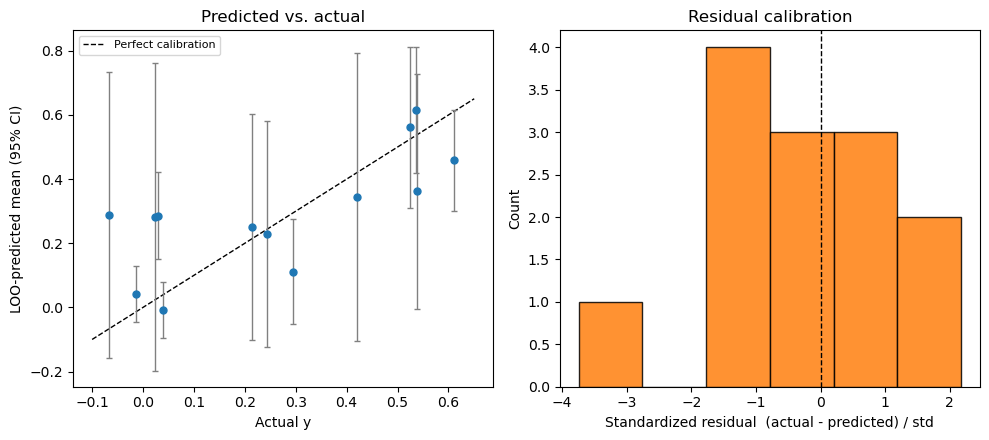

In [10]:
with fitting("leave-one-out calibration"):
    pred_mean, pred_std = loo_predictions(X, y, bounds,
                                          gp_kwargs={"n_restarts_optimizer": 20})

plot_loo_calibration(y, pred_mean, pred_std)
plt.show()

## Iteration diagnostics

Replaying the ordered observations to reconstruct what each past proposal looked like at the time. The history here is mixed, so read the `acq_value` column with care — see the note in the cell.

In [ ]:
# My history is mixed, so the acq_value column needs care: week 2 came from the
# old ucb/kappa=5, week 3 from ei/xi=0.01, week 4 from ucb/kappa=1. Only week 4
# matches what's replayed here. The GP-hyperparameter and domain_mean_std
# columns don't depend on the acquisition and are fine throughout.
with fitting("iteration-diagnostics replay (ucb/kappa=%s; faithful for week 4 only)"
             % KAPPA):
    history = compute_iteration_diagnostics(X, y, bounds, n_initial=n_initial,
                                            acquisition="ucb", kappa=KAPPA,
                                            maximize=True)

plot_bo_diagnostics(history, bounds)
plt.show()

print("Best y so far:", np.nanmax(history["y"]))
print("acq_value is meaningful for week 4 only -- see the comment above.")

## Raw diagnostic fields

In [12]:
print("y:", history["y"])
print("acq_value (NaN = initial batch):", history["acq_value"])
print("\nNOTE: BOTH collected points are artefacts in the acq_value column this")
print("week -- week 2 was proposed under ucb/kappa=5.0 and week 3 under ei/xi=0.01,")
print(f"while the replay above used ucb/kappa={KAPPA}, which matches neither. The")
print("column becomes meaningful from the first point proposed at this kappa.")
print("The GP-hyperparameter and domain_mean_std panels above are unaffected.")

y: [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.0287878   0.53552257
  0.52410349]
acq_value (NaN = initial batch): [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan 0.44019175 0.93747212
 0.94705033]

NOTE: BOTH collected points are artefacts in the acq_value column this
week -- week 2 was proposed under ucb/kappa=5.0 and week 3 under ei/xi=0.01,
while the replay above used ucb/kappa=3.0, which matches neither. The
column becomes meaningful from the first point proposed at this kappa.
The GP-hyperparameter and domain_mean_std panels above are unaffected.


In [ ]:
# My proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision too. I submit the 6-dp string; the store keeps 6 dp as well,
# which is what actually gets evaluated.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))

In [ ]:
# I record this week's proposal in the weekly store. This rewrites inputs.csv
# rather than appending, so re-running the notebook cannot double-record. I
# submit the 6-dp string printed above -- it is the same value written here.
save_proposal(2, new_X, x_next)
